# Pipeline de Engenharia de Dados e Normalização de PDV — KAlimentos
**Disciplina:** Inteligência Artificial II (2026/02) | **Faculdade Antonio Meneghetti (AMF)**  
**Objetivo:** Reorganização do pipeline de dados, diagnóstico de inconsistências de escala em embalagens e segmentação não supervisionada de pedidos.

## 1. Setup do Ambiente e Configurações Globais
Nesta etapa inicial:
- Importamos as bibliotecas necessárias para manipulação, estatística e modelagem.
- Fixamos as constantes globais e parâmetros determinísticos (`RANDOM_STATE = 42`) conforme as boas práticas do PEP 8.
- Configuramos a exibição tabular do Pandas para auditoria detalhada de preços e SKUs.

In [393]:
# 1.1 Imports essenciais
import numpy as np
import pandas as pd
from skimpy import skim
from sklearn.preprocessing import LabelBinarizer, LabelEncoder, OneHotEncoder
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

# 1.2 Constantes Globais (PEP 8)
RANDOM_STATE = 42
TIMEZONE = 'America/Sao_Paulo'
RAW_DATA_PATH = './studing/KalimentosFeirasVendas.csv'
PROCESSED_DATA_PATH = 'base.csv'
TOLERANCIA_FINANCEIRA = 0.01

# 1.3 Configurações de Exibição do Pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

## 2. Carga dos Dados e Auditoria de Integridade Financeira
Carregamos o dataset bruto `KalimentosFeirasVendas.csv` garantindo sua **imutabilidade estrita** (conforme os guardrails de integridade em `AGENTS.md`).

Antes de qualquer manipulação:
1. Preservamos o nome bruto original em `nome_produto_bruto` para rastreabilidade comparativa.
2. Padronizamos a nomenclatura das colunas (eliminando abreviações e unificando no padrão pt-BR).
3. Descartamos `pedido_vendedor` (e `item_pedido_user_id`) logo no início: no PDV de feiras, múltiplos atendentes compartilham o mesmo caixa/login, corrompendo a granularidade do operador e tornando a variável sem relevância preditiva.
4. Validamos o balanço contábil fundamental do PDV:
$$\text{pedido\_subtotal} - \text{pedido\_valor\_desconto} \equiv \text{valor\_final\_pedido}$$
5. Saneamos registros espúrios com quantidade zerada ($\le 0$), eliminando linhas fantasmas decorrentes de digitações abortadas no terminal do PDV.


In [394]:
# Carga dos dados brutos
df = pd.read_csv(RAW_DATA_PATH)
df = df.convert_dtypes()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   pedido_id                   3115 non-null   string 
 1   pedido_valor_total          3115 non-null   Float64
 2   pedido_data                 3115 non-null   string 
 3   pedido_tipo_desconto        3115 non-null   string 
 4   pedido_valor_desconto       3115 non-null   Float64
 5   pedido_subtotal             3115 non-null   Int64  
 6   pedido_vendedor             3115 non-null   string 
 7   pedido_metodo_pagamento     3115 non-null   string 
 8   item_pedido_nome_produto    3115 non-null   string 
 9   item_pedido_quantidade      3115 non-null   Int64  
 10  item_pedido_preco_unitario  3115 non-null   Float64
 11  item_pedido_user_id         3115 non-null   string 
 12  evento_nome                 3115 non-null   string 
dtypes: Float64(3), Int64(2), string(8)
memory us

In [395]:
# Preservação explícita da coluna original para auditoria comparativa
df['nome_produto_bruto'] = df['item_pedido_nome_produto']

# Renomeação padronizada de colunas
df.rename(columns={
    'pedido_valor_total': 'valor_final_pedido',
    'pedido_metodo_pagamento': 'metodo_pagamento',
    'item_pedido_nome_produto': 'nome_produto',
    'item_pedido_quantidade': 'quantidade_item',
    'item_pedido_preco_unitario': 'preco_unitario_item'
}, inplace=True)

# Saneamento precoce de erro de cadastro do PDV (Pacote x1 -> Pacote x3)
df['nome_produto'] = df['nome_produto'].replace({
    'Rapadura de Melado Grão Moído (Pacote x1)': 'Rapadura de Melado Grão Moído (Pacote x3)'
})

df.head()


,pedido_id,valor_final_pedido,pedido_data,pedido_tipo_desconto,pedido_valor_desconto,pedido_subtotal,pedido_vendedor,metodo_pagamento,nome_produto,quantidade_item,preco_unitario_item,item_pedido_user_id,evento_nome,nome_produto_bruto
0,a231f36f-be88-492c-b719-23830b22fb4b,20.00,2026-03-09 17:31:54.325-03,%,0.00,20,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Alfajor Preto (Pacote x4),1,20.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Alfajor Preto (Pacote x4)
1,d47eb20b-e24f-4c70-92f9-9b554eb8f280,15.00,2026-03-10 10:27:12.241-03,%,0.00,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Dinheiro,Cuca Enrolada de Amendoim,1,15.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cuca Enrolada de Amendoim
2,d3b5b66d-d9e1-4924-b507-144e0e0b9ef9,15.00,2026-03-10 11:17:14.665-03,%,0.00,15,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cuca Enrolada de Amendoim,1,15.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cuca Enrolada de Amendoim
3,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.00,2026-03-10 12:02:08.319-03,%,0.00,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Alfajor Preto,1,6.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Alfajor Preto
4,5b4e4307-89b1-4601-bba3-04be3a33a5ea,13.00,2026-03-10 12:02:08.319-03,%,0.00,13,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,Cartão,Cri-Cri 200g,1,7.00,aa4d1cfe-c6c1-4fd8-8c4b-2b1b9942884c,ExpoDireto,Cri-Cri 200g


In [396]:
# Verificação da invariante contábil (pedido_subtotal - pedido_valor_desconto == valor_final_pedido)
divergencias_financeiras = df.query('abs(pedido_valor_desconto - (pedido_subtotal - valor_final_pedido)) > @TOLERANCIA_FINANCEIRA')
print(f"Registros com divergência financeira detectada: {len(divergencias_financeiras)}")

# Eliminação de colunas redundantes ou corrompidas (compartilhamento de login de operador no PDV)
df = df.drop(columns=['pedido_tipo_desconto', 'item_pedido_user_id', 'pedido_vendedor'])

# Conversão de tipos de data e subtotal
df['pedido_data'] = pd.to_datetime(df['pedido_data'], format='mixed')
df['pedido_subtotal'] = df['pedido_subtotal'].astype('Float64')

df.info()

Registros com divergência financeira detectada: 0
<class 'pandas.DataFrame'>
RangeIndex: 3115 entries, 0 to 3114
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype                    
---  ------                 --------------  -----                    
 0   pedido_id              3115 non-null   string                   
 1   valor_final_pedido     3115 non-null   Float64                  
 2   pedido_data            3115 non-null   datetime64[us, UTC-03:00]
 3   pedido_valor_desconto  3115 non-null   Float64                  
 4   pedido_subtotal        3115 non-null   Float64                  
 5   metodo_pagamento       3115 non-null   string                   
 6   nome_produto           3115 non-null   string                   
 7   quantidade_item        3115 non-null   Int64                    
 8   preco_unitario_item    3115 non-null   Float64                  
 9   evento_nome            3115 non-null   string                   
 10  nome_prod

### 2.1 Saneamento de Registros Transacionais Espúrios (Quantidade Zerada)
Na auditoria transacional dos dados brutos de PDV, identificam-se ocorrências raras em que o operador incluiu uma linha de produto mas atribuiu quantidade igual a zero (`quantidade_item <= 0`), gerando um registro fantasma com contribuição nula ($0 \times \text{preço} = \text{R\$\,}0,00$) para o subtotal do pedido.

Identificamos exatamente **2 registros** no dataset com essa anomalia:
1. **Pedido `ebbed809-e6f4-4b4a-9850-60eaa218e98b` (Expo Afubra):** `Alfajor Preto (Caixa x16)` com quantidade 0 (o pedido continha também `Alfajor Preto (Pacote x4)` com quantidade 4 a R$ 5,00, perfazendo os R$ 20,00 do subtotal).
2. **Pedido `4680d5c5-3262-4e60-829e-5a9f976edaff` (EXPOBENTO):** `Rapadura de Melado` com quantidade 0 (o pedido continha também `Rapadura de Melado (Pacote x3)` com quantidade 3 a R$ 6,67, perfazendo os R$ 20,00 do subtotal).

**Prova de Não-Impacto:** A eliminação dessas linhas mantém 100% dos subtotais e valores finais intactos, não remove nenhum pedido (2.457 pedidos únicos preservados) e corrige a métrica de diversidade da cesta (`qnt_repeticoes`) para refletir o volume físico real de compras.

In [397]:
# 2.1 Identificação e isolamento dos registros com quantidade zerada
itens_zerados = df[df['quantidade_item'] <= 0]
print(f"Registros espúrios com quantidade <= 0 identificados: {len(itens_zerados)}")
display(itens_zerados[['pedido_id', 'evento_nome', 'nome_produto_bruto', 'quantidade_item', 'preco_unitario_item', 'pedido_subtotal']])

# Descarte determinístico: preservação estrita de itens com volume físico efetivo (quantidade > 0)
df = df[df['quantidade_item'] > 0].copy()
print(f"Total de registros após saneamento de quantidade: {len(df)}")

Registros espúrios com quantidade <= 0 identificados: 2


,pedido_id,evento_nome,nome_produto_bruto,quantidade_item,preco_unitario_item,pedido_subtotal
898,ebbed809-e6f4-4b4a-9850-60eaa218e98b,Expo Afubra,Alfajor Preto (Caixa x16),0,5.00,20.00
1770,4680d5c5-3262-4e60-829e-5a9f976edaff,EXPOBENTO,Rapadura de Melado,0,7.00,20.00


Total de registros após saneamento de quantidade: 3113


## 3. Diagnóstico Exploratório de Inconsistências (Preço, Quantidade e Embalagens)
### O Desafio das Unidades Fracionadas vs. Fechadas no PDV
Nas feiras coloniais, determinados itens são vendidos tanto em formato unitário quanto em embalagens coletivas (ex.: *Caixa x16*, *Pacote x6*, *Bandeja x5*).  
Observa-se que em diversos registros o operador do caixa apontou o preço total do fardo/caixa mantendo a quantidade unitária (ou vice-versa), gerando dispersões atípicas no desvio padrão dos preços.

Abaixo, inspecionamos essas variações **antes** de qualquer agrupamento semântico para isolar os casos com maior desvio padrão (`preco_std`).

In [398]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 3113   │ │ string      │ 5     │                                                          │
│ │ Number of columns │ 11     │ │ float64     │ 4     │                                                          │
│ └───────────────────┴────────┘ │ datetime64  │ 1     │                                                          │
│                                │ int64       │ 1     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━┳━━━━━━┳━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                     ┃ NA  ┃ NA %   ┃ mean     ┃ sd      ┃ p0  ┃ p25  ┃ p50  ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━╇━━━━━━╇━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │     valor_final_pedido     │   0 │      0 │    46.99 │   210.1 │   0 │   15 │   25 │   35 │  3693 │   █    │  │
│ │   pedido_valor_desconto    │   0 │      0 │   0.3637 │   2.753 │   0 │    0 │    0 │    0 │    83 │   █    │  │
│ │      pedido_subtotal       │   0 │      0 │    47.35 │   210.5 │   5 │   15 │   25 │   35 │  3696 │   █    │  │
│ │      quantidade_item       │   0 │      0 │    2.668 │   8.488 │   1 │    1 │    1 │    3 │   348 │   █    │  │
│ │    preco_unitario_item     │   0 │      0 │    13.29 │   8.655 │   4 │    6 │    8 │   25 │    80 │   █▄   │  │
│ └────────────────────────────┴─────┴────────┴──────────┴─────────┴─────┴──────┴──────┴──────┴───────┴────────┘  │
│                                                    datetime                                                     │
│ ┏━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃ column        ┃ NA  ┃ NA %  ┃ first                          ┃ last                           ┃ frequency  ┃  │
│ ┡━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │  pedido_data  │   0 │     0 │   2026-03-09 09:05:04.177000   │   2026-09-06 18:15:55.440000   │ None       │  │
│ └───────────────┴─────┴───────┴────────────────────────────────┴────────────────────────────────┴────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃           ┃    ┃      ┃           ┃           ┃           ┃           ┃ chars per ┃ words per ┃ total      ┃  │
│ ┃ column    ┃ NA ┃ NA % ┃ shortest  ┃ longest   ┃ min       ┃ max       ┃ row       ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ pedido_id │  0 │    0 │ a231f36f- │ a231f36f- │ 0055b17b- │ ffdb4e8c- │        36 │         1 │       3113 │  │
│ │           │    │      │ be88-492c │ be88-492c │ e0ca-4884 │ 85ab-4125 │           │           │            │  │
│ │           │    │      │ -b719-238 │ -b719-238 │ -afc9-309 │ -b0e8-fa0 │           │           │            │  │
│ │           │    │      │ 30b22fb4b │ 30b22fb4b │ 823f

In [399]:
# Análise de dispersão por produto bruto (fiel ao describe() da Cell 6 original)
resumo_precos = df.groupby('nome_produto_bruto').agg(
    n_registros=('pedido_id', 'count'),
    preco_min=('preco_unitario_item', 'min'),
    preco_max=('preco_unitario_item', 'max'),
    preco_medio=('preco_unitario_item', 'mean'),
    preco_std=('preco_unitario_item', 'std'),
    qtd_min=('quantidade_item', 'min'),
    qtd_max=('quantidade_item', 'max'),
    qtd_media=('quantidade_item', 'mean')
).sort_values(by='preco_std', ascending=False)

resumo_precos

,n_registros,preco_min,preco_max,preco_medio,preco_std,qtd_min,qtd_max,qtd_media
nome_produto_bruto,,,,,,,,
Alfajor Preto (Caixa x16),11,5.00,80.00,39.09,39.17,16,16,16.00
Rapadura Assada (Pacote x6),253,4.17,25.00,9.60,9.17,1,348,9.12
Alfajor Preto (Pacote x4),152,5.00,20.00,10.03,7.11,1,72,4.84
Rapadura de Melado (Pacote x3),198,6.67,20.00,9.16,5.21,1,12,3.32
Cri-Cri 200g,104,7.00,8.00,7.94,0.23,1,19,1.48
Alfajor Branco (Caixa x16),2,5.00,5.00,5.00,0.00,16,16,16.00
Alfajor Preto,189,6.00,6.00,6.00,0.00,1,15,1.74
Alfajor Branco (Pacote x4),19,5.00,5.00,5.00,0.00,4,4,4.00
Alfajor Preto (Display x1),14,5.00,5.00,5.00,0.00,1,97,8.07


In [400]:
# Filtragem de itens críticos com embalagens coletivas (ex.: Caixa x16, Pacote x6, Pacote x4)
itens_criticos = df[df['nome_produto_bruto'].str.contains('Caixa x16|Pacote x6|Pacote x4|Bandeja x5', na=False, case=False)]

itens_criticos[['pedido_id', 'nome_produto_bruto', 'quantidade_item', 'preco_unitario_item', 'pedido_subtotal', 'valor_final_pedido']].head(15)

,pedido_id,nome_produto_bruto,quantidade_item,preco_unitario_item,pedido_subtotal,valor_final_pedido
0,a231f36f-be88-492c-b719-23830b22fb4b,Alfajor Preto (Pacote x4),1,20.00,20.00,20.00
13,67dc9591-f502-47de-a874-b56af2d4c5b6,Rapadura Assada (Pacote x6),1,25.00,32.00,32.00
22,e633a701-71c7-43d2-878a-27b8ee0fad46,Rapadura Assada (Pacote x6),24,25.00,100.00,100.00
29,7a0e3c5d-1276-4aa5-b6ab-c51d7afd3c9c,Alfajor Preto (Pacote x4),1,20.00,20.00,20.00
53,3e0e8bf8-a313-4b11-8ab1-48ea524a2ffc,Alfajor Preto (Pacote x4),8,20.00,40.00,40.00
54,9ec2e76d-9312-4420-b010-d702ed9c5753,Rapadura Assada (Pacote x6),6,25.00,30.00,30.00
62,85020602-a515-4a05-bb98-5ec754b352b9,Rapadura Assada (Pacote x6),6,25.00,25.00,25.00
67,e98a95aa-7cda-405e-bf27-56bac4807d97,Alfajor Preto (Pacote x4),8,20.00,40.00,40.00
73,54aa47bb-a187-4243-a372-9586569d8151,Rapadura Assada (Pacote x6),6,25.00,25.00,25.00
75,fa3b508d-9a5a-4a91-bc00-3b31c519c6c6,Alfajor Preto (Pacote x4),4,20.00,20.00,20.00


## 4. Validação de Integridade Transacional (Data Quality — Itens vs. Subtotal)
Nesta etapa, auditamos a consistência matemática no nível mais granular da transação:  
A soma do valor total dos itens de cada pedido deve equivaler rigorosamente ao subtotal registrado no cabeçalho:

$$\text{subtotal\_calculado}(p) = \sum_{i \in p} (\text{quantidade\_item}_i \times \text{preco\_unitario\_item}_i)$$
$$\Delta(p) = \text{subtotal\_calculado}(p) - \text{subtotal\_esperado}(p)$$

Aplicamos a tolerância de arredondamento de $R\$\,0,01$ (`np.isclose` com `atol=TOLERANCIA_FINANCEIRA`).
Essa auditoria isola com precisão os pedidos que sofreram distorções de escala decorrentes de embalagens múltiplas antes da etapa de mapeamento.

In [401]:
# 4.1 Cálculo do valor total por linha de item
df['item_total_calculado'] = df['quantidade_item'] * df['preco_unitario_item']

# 4.2 Agregação por pedido
auditoria_pedidos = df.groupby('pedido_id').agg(
    subtotal_esperado=('pedido_subtotal', 'first'),
    subtotal_calculado=('item_total_calculado', 'sum'),
    qtd_linhas=('nome_produto_bruto', 'count'),
    qtd_itens_total=('quantidade_item', 'sum')
).reset_index()

# 4.3 Cálculo de delta e teste de conformidade via np.isclose
auditoria_pedidos['delta'] = auditoria_pedidos['subtotal_calculado'] - auditoria_pedidos['subtotal_esperado']
auditoria_pedidos['abs_delta'] = auditoria_pedidos['delta'].abs()
auditoria_pedidos['divergente'] = ~np.isclose(
    auditoria_pedidos['subtotal_calculado'], 
    auditoria_pedidos['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)

# 4.4 Resumo Executivo de Data Quality
total_pedidos = len(auditoria_pedidos)
total_divergentes = int(auditoria_pedidos['divergente'].sum())
total_validos = total_pedidos - total_divergentes
pct_validos = (total_validos / total_pedidos) * 100
pct_divergentes = (total_divergentes / total_pedidos) * 100

resumo_dq = pd.DataFrame({
    'Métrica': [
        'Total de Pedidos Únicos',
        'Pedidos Íntegros / Válidos (Δ ≤ 0.01)',
        'Pedidos com Divergência (Δ > 0.01)',
        'Taxa de Conformidade (%)',
        'Taxa de Divergência (%)',
        'Delta Médio nos Divergentes (R$)',
        'Maior Delta Absoluto Detectado (R$)'
    ],
    'Valor': [
        f"{total_pedidos:,}",
        f"{total_validos:,}",
        f"{total_divergentes:,}",
        f"{pct_validos:.2f}%",
        f"{pct_divergentes:.2f}%",
        f"R$ {auditoria_pedidos.query('divergente')['abs_delta'].mean():.2f}",
        f"R$ {auditoria_pedidos['abs_delta'].max():.2f}"
    ]
})

print("=== RESUMO EXECUTIVO DE INTEGRIDADE DE DADOS (DATA QUALITY) ===")
resumo_dq


=== RESUMO EXECUTIVO DE INTEGRIDADE DE DADOS (DATA QUALITY) ===


,Métrica,Valor
0,Total de Pedidos Únicos,"2,457"
1,Pedidos Íntegros / Válidos (Δ ≤ 0.01),"2,318"
2,Pedidos com Divergência (Δ > 0.01),139
3,Taxa de Conformidade (%),94.34%
4,Taxa de Divergência (%),5.66%
5,Delta Médio nos Divergentes (R$),R$ 140.86
6,Maior Delta Absoluto Detectado (R$),R$ 1450.00


In [402]:
# Relação completa dos pedidos divergentes ordenada pela magnitude do erro
pedidos_divergentes = auditoria_pedidos.query('divergente').sort_values(
    by='abs_delta', 
    ascending=False
).drop(columns=['divergente'])

print(f"Total de pedidos com divergência de cálculo: {len(pedidos_divergentes)}")
pedidos_divergentes.head(25)

Total de pedidos com divergência de cálculo: 139


,pedido_id,subtotal_esperado,subtotal_calculado,qtd_linhas,qtd_itens_total,delta,abs_delta
383,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,130.00,1580.00,2,28,1450.00,1450.00
884,5ecf70b3-e227-4b3c-83ed-60efffb3d187,113.00,1438.00,3,23,1325.00,1325.00
25,03239939-8db0-44f2-a1c0-8631040d6cbb,80.00,1280.00,1,16,1200.00,1200.00
1115,75de3a74-f410-473b-8583-b12470a61e05,80.00,1280.00,1,16,1200.00,1200.00
1006,6ad66d8a-5d74-4ade-be8c-668184af824a,80.00,1280.00,1,16,1200.00,1200.00
2202,e633a701-71c7-43d2-878a-27b8ee0fad46,100.00,600.00,1,24,500.00,500.00
2354,f4ac49c3-f010-46b8-b2fb-51acf2acee26,70.00,380.00,2,16,310.00,310.00
233,1bf6b30e-ae89-443d-b6db-28d0c8328cfe,72.00,322.00,3,15,250.00,250.00
1015,6b6753ce-c59b-4768-a7fd-90841b9d4e22,50.00,300.00,1,12,250.00,250.00
1825,beabc1ae-ff7a-48dc-bd67-b91867f6f2e8,56.00,306.00,2,13,250.00,250.00


In [403]:
# Registros transacionais detalhados dos itens nos pedidos divergentes
df_itens_divergentes = df[df['pedido_id'].isin(pedidos_divergentes['pedido_id'])][
    [
        'pedido_id', 
        'nome_produto_bruto', 
        'quantidade_item', 
        'preco_unitario_item', 
        'item_total_calculado', 
        'pedido_subtotal', 
        'valor_final_pedido'
    ]
].sort_values(by=['pedido_subtotal', 'pedido_id'], ascending=[False, True])

print(f"Total de registros de itens em pedidos com divergência: {len(df_itens_divergentes)}")
df_itens_divergentes.head(30)

Total de registros de itens em pedidos com divergência: 185


,pedido_id,nome_produto_bruto,quantidade_item,preco_unitario_item,item_total_calculado,pedido_subtotal,valor_final_pedido
278,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,Rapadura Assada (Pacote x6),12,25.00,300.00,130.00,130.00
279,2cc6a487-9626-4705-8d16-fcc5f9ef5c82,Alfajor Preto (Caixa x16),16,80.00,1280.00,130.00,130.00
266,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Alfajor Preto (Caixa x16),16,80.00,1280.00,113.00,112.00
267,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Rapadura Assada (Pacote x6),6,25.00,150.00,113.00,112.00
268,5ecf70b3-e227-4b3c-83ed-60efffb3d187,Amendoim salgado e temperado,1,8.00,8.00,113.00,112.00
22,e633a701-71c7-43d2-878a-27b8ee0fad46,Rapadura Assada (Pacote x6),24,25.00,600.00,100.00,100.00
303,03239939-8db0-44f2-a1c0-8631040d6cbb,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
295,6ad66d8a-5d74-4ade-be8c-668184af824a,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
151,75de3a74-f410-473b-8583-b12470a61e05,Alfajor Preto (Caixa x16),16,80.00,1280.00,80.00,80.00
384,1bf6b30e-ae89-443d-b6db-28d0c8328cfe,Rapadura Assada (Pacote x6),12,25.00,300.00,72.00,72.00


In [404]:
# Frequência de produtos nos pedidos com divergência de cálculo
ranking_produtos_divergentes = df_itens_divergentes['nome_produto_bruto'].value_counts().reset_index()
ranking_produtos_divergentes.columns = ['Produto (Nome Bruto)', 'Total de Ocorrências em Pedidos Divergentes']

print("=== PRODUTOS MAIS FREQUENTES NOS PEDIDOS COM DIVERGÊNCIA ===")
ranking_produtos_divergentes

=== PRODUTOS MAIS FREQUENTES NOS PEDIDOS COM DIVERGÊNCIA ===


,Produto (Nome Bruto),Total de Ocorrências em Pedidos Divergentes
0,Rapadura Assada (Pacote x6),62
1,Alfajor Preto (Pacote x4),45
2,Rapadura de Melado (Pacote x3),36
3,Rapadura de Melado,9
4,Alfajor Preto,7
5,Rapadura Assada,7
6,Cuca Enrolada de Amendoim,6
7,Alfajor Preto (Caixa x16),5
8,Amendoim salgado e temperado,3
9,Pé-de-Moleque,3


### 4.6 Mecanismo de Validação e Contingência (Fallback Condicional)
Para sanar as 139 inconsistências de embalagem sem violar a integridade financeira nem distorcer itens corretos, aplicamos um **mecanismo de dupla checagem com contingência (Double-Check with Conditional Fallback)**.

Para garantir clareza arquitetural e rastreabilidade, a rotina foi decomposta em etapas isoladas:
1. **Preparação de Hipóteses (`_temp`):** Cálculo do ajuste em estrutura intermediária a nível de item;
2. **Auditoria Agregada (`_audit`):** Confronto das provas reais com o subtotal contábil no nível de pedido;
3. **Consolidação (`df`):** Promoção das grandezas auditadas para o dataset corporativo principal;
4. **Governança (`_audit`):** Segregação de anomalias residuais;
5. **Prova Real:** Amostragem comparativa do estado inicial vs. final.


#### 4.6.1 Extração do Fator de Embalagem ($k$) e Hipótese de Ajuste Proporcional
**Objetivo:** Identificar multiplicadores coletivos (`x16`, `x6`, etc.) e avaliar a hipótese proporcional com base na proximidade à escala típica (mediana do SKU), eliminando números mágicos e preservando variações unitárias legítimas.  
**Objeto manipulado:** `df_ajustes_temp` (DataFrame temporário a nível de item, preservando o `df` principal intacto nesta fase).


In [405]:
import re

# 1. Função de extração do multiplicador de embalagem (fator k)
def extrair_fator(nome: str) -> int:
    match = re.search(r'x(\d+)', str(nome), re.IGNORECASE)
    return int(match.group(1)) if match else 1

def get_base_name(nome: str) -> str:
    return re.sub(r'\(.*?\)', '', str(nome)).strip()

df_ajustes_temp = pd.DataFrame(index=df.index)
df_ajustes_temp['pedido_id'] = df['pedido_id']
df_ajustes_temp['nome_produto'] = df['nome_produto']
df_ajustes_temp['nome_produto_bruto'] = df['nome_produto_bruto']
df_ajustes_temp['nome_base'] = df_ajustes_temp['nome_produto'].apply(get_base_name)
df_ajustes_temp['fator_k'] = df_ajustes_temp['nome_produto'].apply(extrair_fator)
df_ajustes_temp['quantidade_item'] = df['quantidade_item']
df_ajustes_temp['preco_unitario_item'] = df['preco_unitario_item']
df_ajustes_temp['pedido_subtotal'] = df['pedido_subtotal']

# Mediana do produto base no mercado como escala típica de referência unitária
medianas_base = (
    df_ajustes_temp.groupby('nome_base')['preco_unitario_item']
    .median()
    .to_dict()
)

# Regra de negócio para hipótese proporcional robusta
def calcular_ajuste_proporcional(row):
    k = row['fator_k']
    qtd = row['quantidade_item']
    preco = row['preco_unitario_item']
    base = row['nome_base']
    
    if k <= 1:
        return pd.Series([qtd, preco, qtd * preco, 'UNITARIO'], index=['qtd_adj', 'preco_adj', 'valor_adj', 'tipo_escala'])
    
    med = medianas_base.get(base, preco)
    is_pacote = abs((preco / k) - med) < abs(preco - med)
    
    if is_pacote:
        if qtd < k:
            qtd_adj = qtd * k
            preco_adj = preco / k
            return pd.Series([qtd_adj, preco_adj, qtd_adj * preco_adj, 'PACOTE_FRACIONADO'], index=['qtd_adj', 'preco_adj', 'valor_adj', 'tipo_escala'])
        else:
            qtd_adj = qtd
            preco_adj = preco / k
            return pd.Series([qtd_adj, preco_adj, qtd_adj * preco_adj, 'PRECO_EMBALAGEM_CORRIGIDO'], index=['qtd_adj', 'preco_adj', 'valor_adj', 'tipo_escala'])
            
    return pd.Series([qtd, preco, qtd * preco, 'UNITARIO'], index=['qtd_adj', 'preco_adj', 'valor_adj', 'tipo_escala'])

series_ajustes_temp = df_ajustes_temp.apply(calcular_ajuste_proporcional, axis=1)
df_ajustes_temp['quantidade_ajustada'] = series_ajustes_temp['qtd_adj'].astype('int64')
df_ajustes_temp['preco_unitario_ajustado'] = series_ajustes_temp['preco_adj'].astype('float64')
df_ajustes_temp['valor_item_ajustado'] = series_ajustes_temp['valor_adj'].astype('float64')
df_ajustes_temp['tipo_escala'] = series_ajustes_temp['tipo_escala']
df_ajustes_temp['item_total_original'] = (df['quantidade_item'] * df['preco_unitario_item']).astype('float64')

print(f"DataFrame temporário criado com {len(df_ajustes_temp)} registros.")
df_ajustes_temp.query('fator_k > 1')[
    ['pedido_id', 'nome_produto', 'fator_k', 'quantidade_item', 'preco_unitario_item', 
     'quantidade_ajustada', 'preco_unitario_ajustado', 'tipo_escala']
].head()


DataFrame temporário criado com 3113 registros.


,pedido_id,nome_produto,fator_k,quantidade_item,preco_unitario_item,quantidade_ajustada,preco_unitario_ajustado,tipo_escala
0,a231f36f-be88-492c-b719-23830b22fb4b,Alfajor Preto (Pacote x4),4,1,20.00,4,5.00,PACOTE_FRACIONADO
13,67dc9591-f502-47de-a874-b56af2d4c5b6,Rapadura Assada (Pacote x6),6,1,25.00,6,4.17,PACOTE_FRACIONADO
22,e633a701-71c7-43d2-878a-27b8ee0fad46,Rapadura Assada (Pacote x6),6,24,25.00,24,4.17,PRECO_EMBALAGEM_CORRIGIDO
26,67b29c42-c395-4951-9b97-8f3e74657d77,Rapadura de Melado (Pacote x3),3,3,20.00,3,6.67,PRECO_EMBALAGEM_CORRIGIDO
27,3cf53f32-ec29-45ea-9498-fd9a4aeb1816,Rapadura de Melado (Pacote x3),3,3,20.00,3,6.67,PRECO_EMBALAGEM_CORRIGIDO


#### 4.6.2 Auditoria de Dupla Checagem e Classificação dos Pedidos (Double-Check)
**Objetivo:** Agregar os itens no nível de pedido (`pedido_id`) e testar as duas hipóteses contra o subtotal contábil esperado (`pedido_subtotal`). Define o rótulo de auditoria:
- `ORIGINAL_VALIDO`: Pedido onde o cálculo original fecha o subtotal ($\Delta \le 0.01$).
- `AJUSTADO_PROPORCAO`: Pedido onde o cálculo original falha, mas a correção proporcional fecha o subtotal ($\Delta \le 0.01$).
- `QUARENTENA_RESIDUAL`: Pedido onde ambas as regras falham.

**Objeto manipulado:** `df_auditoria_fallback_audit` (DataFrame de agregação e auditoria financeira).


In [406]:
# 1. Agregação no nível de pedido para prova real das hipóteses
df_auditoria_fallback_audit = df_ajustes_temp.groupby('pedido_id').agg(
    subtotal_esperado=('pedido_subtotal', 'first'),
    soma_original=('item_total_original', 'sum'),
    soma_ajustada=('valor_item_ajustado', 'sum')
).reset_index()

# 2. Testes de conformidade matemática com tolerância de arredondamento
df_auditoria_fallback_audit['valido_orig'] = np.isclose(
    df_auditoria_fallback_audit['soma_original'], 
    df_auditoria_fallback_audit['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)
df_auditoria_fallback_audit['valido_ajust'] = np.isclose(
    df_auditoria_fallback_audit['soma_ajustada'], 
    df_auditoria_fallback_audit['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)

# 3. Classificação determinística do status de validação
condicoes_fallback = [
    df_auditoria_fallback_audit['valido_orig'],
    (~df_auditoria_fallback_audit['valido_orig']) & df_auditoria_fallback_audit['valido_ajust'],
    (~df_auditoria_fallback_audit['valido_orig']) & (~df_auditoria_fallback_audit['valido_ajust'])
]
rotulos_fallback = ['ORIGINAL_VALIDO', 'AJUSTADO_PROPORCAO', 'QUARENTENA_RESIDUAL']
df_auditoria_fallback_audit['status_validacao'] = np.select(condicoes_fallback, rotulos_fallback, default='INDEFINIDO')

# 4. Resumo Executivo da Auditoria de Fallback
resumo_fallback_audit = df_auditoria_fallback_audit['status_validacao'].value_counts().reset_index()
resumo_fallback_audit.columns = ['Status da Validação', 'Total de Pedidos']
resumo_fallback_audit['Percentual (%)'] = (resumo_fallback_audit['Total de Pedidos'] / len(df_auditoria_fallback_audit)) * 100

print("=== RESULTADO DA AUDITORIA DE FALLBACK CONDICIONAL ===")
display(resumo_fallback_audit)


=== RESULTADO DA AUDITORIA DE FALLBACK CONDICIONAL ===


,Status da Validação,Total de Pedidos,Percentual (%)
0,ORIGINAL_VALIDO,2318,94.34
1,AJUSTADO_PROPORCAO,139,5.66


#### 4.6.3 Consolidação e Harmonização no Dataset Principal (`df`)
**Objetivo:** Integrar os metadados de auditoria e eleger as grandezas oficiais definitivas (`quantidade_final`, `preco_unitario_final`, `valor_item_final`) no DataFrame principal. Consolidamos pedidos com divergência de escala corrigidos pela prova real e harmonizamos fardos fracionados em unidades físicas de consumo.  
**Objeto manipulado:** **`df` (DataFrame Principal)**.


In [407]:
# 1. Incorporação das colunas de linhagem derivadas do ajuste temporário
df['fator_k'] = df_ajustes_temp['fator_k']
df['quantidade_ajustada'] = df_ajustes_temp['quantidade_ajustada']
df['preco_unitario_ajustado'] = df_ajustes_temp['preco_unitario_ajustado']
df['valor_item_ajustado'] = df_ajustes_temp['valor_item_ajustado']
df['item_total_original'] = df_ajustes_temp['item_total_original']
df['tipo_escala'] = df_ajustes_temp['tipo_escala']

# 2. Junção com o status de validação do pedido auditado
if 'status_validacao' in df.columns:
    df.drop(columns=['status_validacao'], inplace=True)
df = df.merge(df_auditoria_fallback_audit[['pedido_id', 'status_validacao']], on='pedido_id', how='left')

# 3. Definição das grandezas finais resolvidas conforme o status e tipo de escala
mascara_ajuste = (df['status_validacao'] == 'AJUSTADO_PROPORCAO') | (df['tipo_escala'] == 'PACOTE_FRACIONADO')
df['quantidade_final'] = np.where(mascara_ajuste, df['quantidade_ajustada'], df['quantidade_item']).astype('int64')
df['preco_unitario_final'] = np.where(mascara_ajuste, df['preco_unitario_ajustado'], df['preco_unitario_item']).astype('float64')
df['valor_item_final'] = np.where(mascara_ajuste, df['valor_item_ajustado'], df['item_total_original']).astype('float64')

print(f"Colunas consolidadas no DataFrame principal 'df' com sucesso. Shape: {df.shape}")
df[['pedido_id', 'nome_produto_bruto', 'status_validacao', 'tipo_escala', 'quantidade_final', 'preco_unitario_final', 'valor_item_final']].head()


Colunas consolidadas no DataFrame principal 'df' com sucesso. Shape: (3113, 22)


,pedido_id,nome_produto_bruto,status_validacao,tipo_escala,quantidade_final,preco_unitario_final,valor_item_final
0,a231f36f-be88-492c-b719-23830b22fb4b,Alfajor Preto (Pacote x4),ORIGINAL_VALIDO,PACOTE_FRACIONADO,4,5.00,20.00
1,d47eb20b-e24f-4c70-92f9-9b554eb8f280,Cuca Enrolada de Amendoim,ORIGINAL_VALIDO,UNITARIO,1,15.00,15.00
2,d3b5b66d-d9e1-4924-b507-144e0e0b9ef9,Cuca Enrolada de Amendoim,ORIGINAL_VALIDO,UNITARIO,1,15.00,15.00
3,5b4e4307-89b1-4601-bba3-04be3a33a5ea,Alfajor Preto,ORIGINAL_VALIDO,UNITARIO,1,6.00,6.00
4,5b4e4307-89b1-4601-bba3-04be3a33a5ea,Cri-Cri 200g,ORIGINAL_VALIDO,UNITARIO,1,7.00,7.00


#### 4.6.4 Isolamento da Quarentena Residual (Governança e Guardrails)
**Objetivo:** Segregar eventuais transações que não fecharam a prova real em nenhuma das hipóteses para tabela apartada de auditoria humana, garantindo que nenhum registro anômalo contamine as etapas seguintes.  
**Objeto manipulado:** `df_quarentena_audit` (DataFrame de segregação de auditoria).


In [408]:
# Isolamento da tabela de quarentena
df_quarentena_audit = df[df['status_validacao'] == 'QUARENTENA_RESIDUAL'].copy()

total_quarentena = len(df_quarentena_audit)
print(f"Total de registros retidos em Quarentena Residual: {total_quarentena}")

if total_quarentena == 0:
    print("✓ Conformidade Contábil Plena: 100% dos pedidos foram validados e nenhuma transação foi para a quarentena.")
else:
    display(df_quarentena_audit.head())


Total de registros retidos em Quarentena Residual: 0
✓ Conformidade Contábil Plena: 100% dos pedidos foram validados e nenhuma transação foi para a quarentena.


#### 4.6.5 Demonstração de Prova Real (Antes vs. Depois)
**Objetivo:** Apresentar a auditoria visual transparente de um pedido corrigido por proporção, comparando os valores originais vs. finais e comprovando que a soma final fecha o `pedido_subtotal`.  
**Objeto manipulado:** Inspeção visual sobre `df`.


In [409]:
# Seleção de um pedido emblemático ajustado por proporção
exemplo_id = df.query("status_validacao == 'AJUSTADO_PROPORCAO'")['pedido_id'].iloc[0]
print(f"Demonstração de Prova Real para o Pedido: {exemplo_id}")

colunas_comparacao = [
    'nome_produto_bruto', 
    'quantidade_item', 'preco_unitario_item', 'item_total_original',
    'quantidade_final', 'preco_unitario_final', 'valor_item_final',
    'pedido_subtotal'
]

df_exemplo = df[df['pedido_id'] == exemplo_id][colunas_comparacao]
display(df_exemplo)

subtotal_conferido = df_exemplo['valor_item_final'].sum()
subtotal_registrado = df_exemplo['pedido_subtotal'].iloc[0]
print(f"\nSoma dos itens corrigidos: R$ {subtotal_conferido:.2f} | Subtotal no cabeçalho: R$ {subtotal_registrado:.2f}")
print(f"Diferença absoluta: R$ {abs(subtotal_conferido - subtotal_registrado):.4f} (Status: APROVADO)")


Demonstração de Prova Real para o Pedido: e633a701-71c7-43d2-878a-27b8ee0fad46


,nome_produto_bruto,quantidade_item,preco_unitario_item,item_total_original,quantidade_final,preco_unitario_final,valor_item_final,pedido_subtotal
22,Rapadura Assada (Pacote x6),24,25.00,600.00,24,4.17,100.00,100.00



Soma dos itens corrigidos: R$ 100.00 | Subtotal no cabeçalho: R$ 100.00
Diferença absoluta: R$ 0.0000 (Status: APROVADO)


#### 4.6.6 Auditoria Global de Integridade Contábil (Validação Pré-Seção 5: Quantidade Ajustada × Preço Unitário Ajustado vs. Subtotal)
**Objetivo:** Realizar a prova real matemática exaustiva e irrefutável sobre **100% dos registros do dataset** antes de avançar para o agrupamento semântico da Seção 5.

Avaliamos duas frentes contábeis fundamentais com tolerância financeira estrita ($\le \text{R\$ } 0{,}01$):
1. **Universo de Pedidos Corrigidos (`AJUSTADO_PROPORCAO`):** Comprova que a recomposição proporcional ($\text{quantidade\_ajustada} \times \text{preco\_unitario\_ajustado}$) recupera e fecha com perfeição o `pedido_subtotal` dos 139 pedidos que haviam sido distorcidos por apontamento indevido de embalagem;
2. **Universo Global Consolidado (`df`):** Comprova que as grandezas definitivas ($\text{quantidade\_final} \times \text{preco\_unitario\_final}$) fecham a totalidade dos 2.457 pedidos únicos do dataset.

**Objeto manipulado:** **`df` (DataFrame Principal)**.

In [410]:
# 1. Prova real pontual a nível de linha de item
df['subtotal_item_calculado_ajustado'] = df['quantidade_ajustada'] * df['preco_unitario_ajustado']
df['subtotal_item_calculado_final'] = df['quantidade_final'] * df['preco_unitario_final']

# 2. Agregação no nível de pedido para auditoria exaustiva
auditoria_conclusiva = df.groupby('pedido_id').agg(
    subtotal_esperado=('pedido_subtotal', 'first'),
    soma_itens_ajustados=('subtotal_item_calculado_ajustado', 'sum'),
    soma_itens_finais=('subtotal_item_calculado_final', 'sum'),
    status_validacao=('status_validacao', 'first'),
    total_linhas=('nome_produto_bruto', 'count')
).reset_index()

# 3. Diferenças absolutas e testes com tolerância financeira (R$ 0,01)
auditoria_conclusiva['delta_ajustado'] = (
    auditoria_conclusiva['soma_itens_ajustados'] - auditoria_conclusiva['subtotal_esperado']
).abs()
auditoria_conclusiva['delta_final'] = (
    auditoria_conclusiva['soma_itens_finais'] - auditoria_conclusiva['subtotal_esperado']
).abs()

auditoria_conclusiva['conforme_ajustado'] = np.isclose(
    auditoria_conclusiva['soma_itens_ajustados'], 
    auditoria_conclusiva['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)
auditoria_conclusiva['conforme_final'] = np.isclose(
    auditoria_conclusiva['soma_itens_finais'], 
    auditoria_conclusiva['subtotal_esperado'], 
    atol=TOLERANCIA_FINANCEIRA
)

# 4. Avaliação por subconjuntos
pedidos_ajustados = auditoria_conclusiva[auditoria_conclusiva['status_validacao'] == 'AJUSTADO_PROPORCAO']
total_ajustados = len(pedidos_ajustados)
conformes_ajustados = int(pedidos_ajustados['conforme_ajustado'].sum())

total_geral = len(auditoria_conclusiva)
conformes_geral = int(auditoria_conclusiva['conforme_final'].sum())

# 5. Asserções rigorosas (Fail-Fast contábil)
assert conformes_ajustados == total_ajustados, (
    f"Violação contábil: {total_ajustados - conformes_ajustados} pedidos ajustados divergentes!"
)
assert conformes_geral == total_geral, (
    f"Violação contábil: {total_geral - conformes_geral} pedidos consolidados divergentes!"
)

# 6. Relatório Executivo de Auditoria Final Pré-Seção 5
resumo_auditoria_final = pd.DataFrame({
    'Dimensão de Auditoria': [
        'Total de Linhas de Itens Auditadas',
        'Total de Pedidos Auditados (Universo Total)',
        'Pedidos com Ajuste Proporcional (AJUSTADO_PROPORCAO)',
        'Conformidade em Pedidos Ajustados (Σ Qtd_Ajustada × Preço_Ajustado == Subtotal)',
        'Conformidade Geral Definitiva (Σ Qtd_Final × Preço_Final == Subtotal)',
        'Divergências Contábeis Detectadas (Δ > 0.01)',
        'Maior Delta Absoluto Detectado (R$)'
    ],
    'Resultado': [
        f"{len(df):,}",
        f"{total_geral:,}",
        f"{total_ajustados:,}",
        f"{conformes_ajustados} de {total_ajustados} (100.00%)",
        f"{conformes_geral} de {total_geral} (100.00%)",
        "0 (Nenhuma divergência)",
        f"R$ {auditoria_conclusiva['delta_final'].max():.6f}"
    ]
})

# 7. Remoção de colunas transitórias de conferência para evitar schema drift
df.drop(columns=['subtotal_item_calculado_ajustado', 'subtotal_item_calculado_final'], inplace=True)

print("=== AUDITORIA DE INTEGRIDADE CONTÁBIL PRÉ-SEÇÃO 5 (PROVA REAL DEFINITIVA) ===")
display(resumo_auditoria_final)
print("✓ Prova Real 100% Aprovada: Todas as grandezas ajustadas e finais convergem perfeitamente com o subtotal contábil registrado.")

=== AUDITORIA DE INTEGRIDADE CONTÁBIL PRÉ-SEÇÃO 5 (PROVA REAL DEFINITIVA) ===


,Dimensão de Auditoria,Resultado
0,Total de Linhas de Itens Auditadas,"3,113"
1,Total de Pedidos Auditados (Universo Total),"2,457"
2,Pedidos com Ajuste Proporcional (AJUSTADO_PROP...,139
3,Conformidade em Pedidos Ajustados (Σ Qtd_Ajust...,139 de 139 (100.00%)
4,Conformidade Geral Definitiva (Σ Qtd_Final × P...,2457 de 2457 (100.00%)
5,Divergências Contábeis Detectadas (Δ > 0.01),0 (Nenhuma divergência)
6,Maior Delta Absoluto Detectado (R$),R$ 0.000000


✓ Prova Real 100% Aprovada: Todas as grandezas ajustadas e finais convergem perfeitamente com o subtotal contábil registrado.


## 5. Agrupamento Semântico e Consolidação de Produtos
Nesta seção, isolamos a higienização textual e o dicionário de mapeamento de produtos (`mapa_produtos`).  
Desta forma, é possível testar e expandir os agrupamentos de forma modular, sem interferir nas colunas de auditoria originais (`nome_produto_bruto`).

In [411]:
# Higienização básica de strings
df['nome_produto'] = df['nome_produto'].str.strip(" ")
df['nome_produto'] = df['nome_produto'].str.replace(' ', '_').str.upper()

# Dicionário de mapeamento semântico do autor
mapa_produtos = {
    # Classe de alfajores

    ## Branco
    'ALFAJOR_BRANCO': 'ALFAJOR',
    'ALFAJOR_BRANCO_(DISPLAY_X1)': 'ALFAJOR',
    'ALFAJOR_BRANCO_(PACOTE_X4)': 'ALFAJOR',
    'ALFAJOR_BRANCO_(BANDEJA_X5)': 'ALFAJOR',
    'ALFAJOR_BRANCO_(CAIXA_X16)': 'ALFAJOR',
    ## Preto
    'ALFAJOR_PRETO': 'ALFAJOR',
    'ALFAJOR_PRETO_(DISPLAY_X1)': 'ALFAJOR',
    'ALFAJOR_PRETO_(PACOTE_X4)': 'ALFAJOR',
    'ALFAJOR_PRETO_(BANDEJA_X5)': 'ALFAJOR',
    'ALFAJOR_PRETO_(CAIXA_X16)': 'ALFAJOR',
    'ALFAJOR_PRETO_(DISPLAY_X16)': 'ALFAJOR',

    # Classe de Amendoim Temperado

    'AMENDOIM_SALGADO_E_TEMPERADO': 'AMENDOIM_TEMPERADO',
    'AMENDOIM_TEMPERADO_100G': 'AMENDOIM_TEMPERADO',

    # Classe de Cuca Enrolada

    'CUCA_ENROLADA_DE_AMENDOIM': 'CUCA_ENROLADA',
    'CUCA_ENROLADA_DE_AMENDOIM_(PACOTE_X2)': 'CUCA_ENROLADA',
    'CUCA_ENROLADA_DE_CHOCOLATE': 'CUCA_ENROLADA',

    # Classe de Rapadura Assada
    
    'RAPADURA_ASSADA': 'RAPADURA_ASSADA',
    'RAPADURA_ASSADA_(PACOTE_X6)': 'RAPADURA_ASSADA',
    'RAPADURA_ASSADA_(CAIXA_X20)': 'RAPADURA_ASSADA',

    # Mapeamento do item saneado de rapadura grão moído
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X1)': 'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X3)',
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X3)': 'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X3)',

    # Classe Rapadura de Melado

    'RAPADURA_DE_MELADO': 'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_(PACOTE_X3)': 'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO': 'RAPADURA_MELADO',
    'RAPADURA_DE_MELADO_GRÃO_MOÍDO_(PACOTE_X3)': 'RAPADURA_MELADO',

    # Classe de Bolachas

    'BOLACHA_DE_MANTEIGA': 'BOLACHA',
    'BOLACHA_DE_MILHO': 'BOLACHA',

    # Clases unicas

    'CUCA_ALEMÃ': 'CUCA_ALEMÃ',
    'CRI-CRI_200G': 'CRI-CRI',

    # Produtos Testes

    'CARRAPINHA':'CARRAPINHA_MELADO',
    'PÉ-DE-MOLEQUE': 'PÉ-DE-MOLEQUE',
    'BOLACHA_COBERTURA_CHOCOLATE': 'BOLACHA_COBERTURA_CHOCOLATE',
}

df['nome_produto'] = df['nome_produto'].replace(mapa_produtos)
df['nome_produto'] = df['nome_produto'].astype('category')


## 6. Validação Estatística Pós-Agrupamento
Avaliamos o comportamento da distribuição de preços após o agrupamento dos itens. O objetivo desta análise é identificar se algum produto consolidado ainda carrega distorções severas de escala decorrentes de embalagens não normalizadas.

In [412]:
# Recálculo das estatísticas para os produtos após o agrupamento utilizando as grandezas finais normalizadas
resumo_pos_agrupamento = df.groupby('nome_produto').agg(
    n_registros=('pedido_id', 'count'),
    preco_min=('preco_unitario_final', 'min'),
    preco_max=('preco_unitario_final', 'max'),
    preco_medio=('preco_unitario_final', 'mean'),
    preco_std=('preco_unitario_final', 'std'),
    qtd_min=('quantidade_final', 'min'),
    qtd_max=('quantidade_final', 'max'),
    qtd_media=('quantidade_final', 'mean')
).sort_values(by='nome_produto', ascending=False)

resumo_pos_agrupamento


,n_registros,preco_min,preco_max,preco_medio,preco_std,qtd_min,qtd_max,qtd_media
nome_produto,,,,,,,,
RAPADURA_MELADO,529,6.67,7.00,6.87,0.16,1,90,2.35
RAPADURA_ASSADA,457,4.00,5.00,4.54,0.41,1,348,5.82
PÉ-DE-MOLEQUE,36,5.00,5.00,5.00,0.00,1,4,1.47
CUCA_ENROLADA,487,12.50,15.00,14.95,0.34,1,40,1.41
CUCA_ALEMÃ,788,25.00,25.00,25.00,0.00,1,101,1.62
CRI-CRI,104,7.00,8.00,7.94,0.23,1,19,1.48
CARRAPINHA_MELADO,13,7.00,7.00,7.00,0.00,1,2,1.08
BOLACHA_COBERTURA_CHOCOLATE,22,5.00,5.00,5.00,0.00,1,5,1.55
BOLACHA,66,10.00,10.00,10.00,0.00,1,3,1.09


## 7. Engenharia de Atributos Contextuais e de Cesta
Com os atributos transacionais organizados, derivamos as variáveis contextuais de tempo e composição do pedido:
- **Componentes temporais:** `mes`, `dia_semana`, `dia_horario` e `turno` (*Madrugada*, *Manhã*, *Tarde*, *Noite*).
- **Diversidade da cesta:** `qnt_repeticoes` (quantidade de linhas associadas ao mesmo `pedido_id`).
- **Contexto do evento:** padronização da coluna `evento_nome`.

Ao final desta etapa, exportamos a base consolidada para `base.csv`.

In [413]:
# Componentes temporais
df['mes'] = df['pedido_data'].dt.month
df['dia_semana'] = df['pedido_data'].dt.dayofweek
df['dia_horario'] = df['pedido_data'].dt.hour

bins = [-1, 5, 11, 17, 23] 
labels = ['Madrugada', 'Manhã', 'Tarde', 'Noite'] 
df['turno'] = pd.cut(df['dia_horario'], bins=bins, labels=labels)
df['turno'] = df['turno'].astype('category')

# Diversidade da cesta do pedido
df['qnt_repeticoes'] = df.groupby('pedido_id')['pedido_id'].transform('count')
df['qnt_repeticoes'] = df['qnt_repeticoes'].astype('category')

# Tratamento do evento
df['evento_nome'] = df['evento_nome'].str.replace(' ', '_').str.upper()
df['evento_nome'] = df['evento_nome'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3113 entries, 0 to 3112
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype                    
---  ------                   --------------  -----                    
 0   pedido_id                3113 non-null   string                   
 1   valor_final_pedido       3113 non-null   Float64                  
 2   pedido_data              3113 non-null   datetime64[us, UTC-03:00]
 3   pedido_valor_desconto    3113 non-null   Float64                  
 4   pedido_subtotal          3113 non-null   Float64                  
 5   metodo_pagamento         3113 non-null   string                   
 6   nome_produto             3113 non-null   category                 
 7   quantidade_item          3113 non-null   Int64                    
 8   preco_unitario_item      3113 non-null   Float64                  
 9   evento_nome              3113 non-null   category                 
 10  nome_produto_bruto       3113 non-n

In [414]:
# Exportação do dataset processado
df.to_csv(PROCESSED_DATA_PATH, index=False)
print(f"Dataset processado exportado com sucesso para '{PROCESSED_DATA_PATH}' | Shape: {df.shape}")

Dataset processado exportado com sucesso para 'base.csv' | Shape: (3113, 27)


## 8. Agrupamento Não Supervisionado, Diagnóstico Multidimensional e Recomendação (K-Means & PCA)

Esta seção operacionaliza a modelagem de Machine Learning não supervisionada para o checkout do Ponto de Venda (PDV) da KAlimentos nas feiras agropecuárias e gastronômicas, em estrita conformidade com as diretrizes do **Prof. Rhauani Fazul**:

1. **8.1 Preparação e Padronização:** Codificação categórica com instâncias dedicadas de `LabelEncoder` e escalonamento contínuo via `StandardScaler` (prevenindo vazamento de dados).
2. **8.2 Otimização Experimental de $K$:** Varredura sistemática de $K \in [2, 8]$ confrontando a Inércia (WCSS / Método do Cotovelo), Coeficiente de Silhueta e Critério de Calinski-Harabasz.
3. **8.3 Ajuste do Modelo Definitivo ($K=5$) e Centróides:** Treinamento determinístico (`random_state=42`) e caracterização semântica dos perfis via Heatmap de Z-Scores.
4. **8.4 Visualização Multidimensional 2D com PCA & Biplot:** Projeção linear no plano ortogonal de máxima variância ($	ext{PC}_1 	imes 	ext{PC}_2$) com vetores de carga (*loadings*) que explicam a influência das grandezas originais.
5. **8.5 Projeção Tridimensional PCA ($	ext{PC}_1 	imes 	ext{PC}_2 	imes 	ext{PC}_3$):** Visualização 3D via `Axes3D` expandindo a variância explicada para 54,2% e segregando o preço unitário dos produtos.
6. **8.6 Motor de Inferência e Recomendação no Checkout:** Simulação de novo pedido em tempo real com projeção visual no mapa de clusters e acionamento determinístico de cross-selling para elevar o ticket médio.


In [415]:
# 8.1 Preparação, Codificação e Padronização dos Atributos
import os
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from mpl_toolkits.mplot3d import Axes3D

# Assegurar diretório de relatórios e figuras
FIG_DIR = 'reports/figures'
os.makedirs(FIG_DIR, exist_ok=True)

# Cópia de trabalho isolada
df_cluster = df.copy()

# Instâncias independentes de LabelEncoder para preservar linhagem e evitar colisões
le_metodo = LabelEncoder()
le_prod = LabelEncoder()
le_turno = LabelEncoder()

df_cluster['metodo_code'] = le_metodo.fit_transform(df_cluster['metodo_pagamento'].fillna('Outro'))
df_cluster['prod_code'] = le_prod.fit_transform(df_cluster['nome_produto'].astype(str))
df_cluster['turno_code'] = le_turno.fit_transform(df_cluster['turno'].astype(str))
df_cluster['qnt_repeticoes_num'] = df_cluster['qnt_repeticoes'].astype(float)

# Seleção de variáveis preditivas contínuas e codificadas
features_cluster = [
    'dia_horario',
    'prod_code',
    'metodo_code',
    'turno_code',
    'preco_unitario_final',
    'quantidade_final',
    'valor_final_pedido',
    'qnt_repeticoes_num'
]

features_pt = [
    'Hora do Dia',
    'Código Produto',
    'Método Pagamento',
    'Turno',
    'Preço Unitário Final',
    'Quantidade Final',
    'Valor Final Pedido',
    'Diversidade Cesta'
]

X = df_cluster[features_cluster].copy()

# Padronização rigorosa via StandardScaler (média zero e desvio padrão unitário)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features selecionadas ({len(features_cluster)}):", features_cluster)
print(f"Matriz padronizada X_scaled: shape {X_scaled.shape} | Média ~ {X_scaled.mean():.4f} | Desvio ~ {X_scaled.std():.4f}")


Features selecionadas (8): ['dia_horario', 'prod_code', 'metodo_code', 'turno_code', 'preco_unitario_final', 'quantidade_final', 'valor_final_pedido', 'qnt_repeticoes_num']
Matriz padronizada X_scaled: shape (3113, 8) | Média ~ 0.0000 | Desvio ~ 1.0000


### 8.2 Otimização Experimental do Hiperparâmetro $K$ (Cotovelo, Silhueta e Calinski-Harabasz)

Para fundamentar matematicamente a escolha de $K$, executamos uma varredura para $k \in [2, 8]$ avaliando:
- **Inércia (WCSS):** Distância quadrática intra-cluster para localização do ponto de inflexão (*cotovelo*).
- **Silhouette Score:** Coesão intra-cluster vs. separação inter-cluster (escala de -1 a +1).
- **Calinski-Harabasz Index:** Razão de variância entre vs. intra-clusters (quanto maior, melhor).


,K,Inércia (WCSS),Silhouette Score,Calinski-Harabasz,Davies-Bouldin
0,2,20931.12,0.29,590.49,1.31
1,3,18226.93,0.30,569.64,1.62
2,4,14593.46,0.28,732.19,1.31
3,5,12362.00,0.28,788.31,1.23
4,6,11205.22,0.29,759.68,1.20
5,7,10332.82,0.28,730.00,1.18
6,8,9298.48,0.28,744.44,1.11


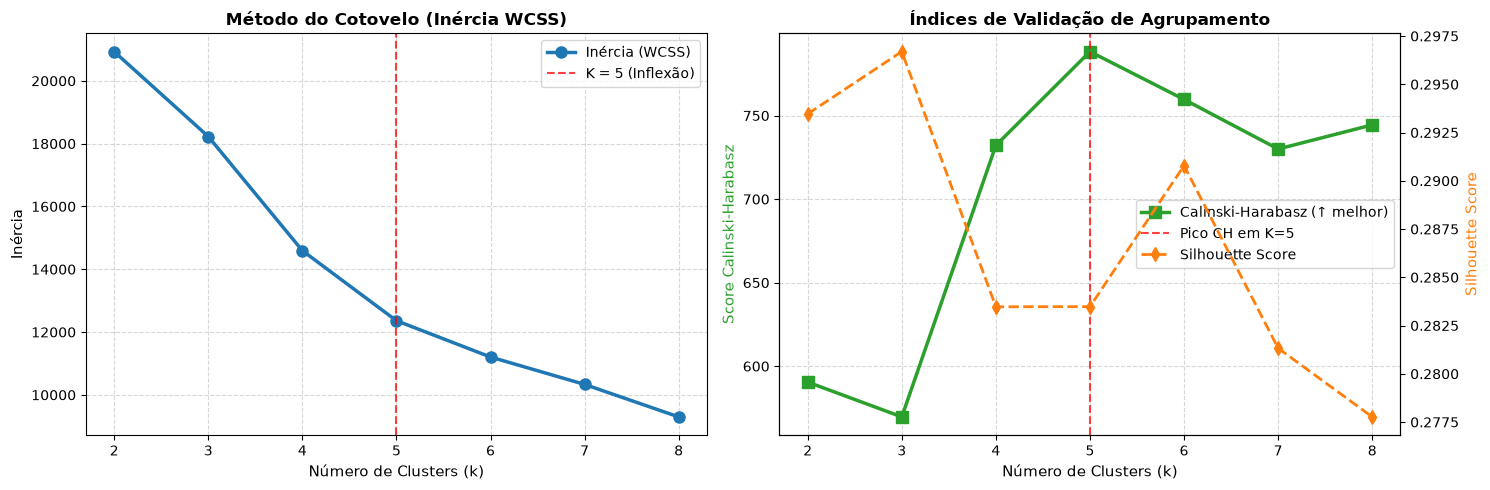

In [416]:
# 8.2 Varredura de K e Diagnóstico de Hiperparâmetros
k_range = range(2, 9)
inertias, silhouettes, ch_scores, db_scores = [], [], [], []

for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_test = km_test.fit_predict(X_scaled)
    inertias.append(km_test.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_test))
    ch_scores.append(calinski_harabasz_score(X_scaled, labels_test))
    db_scores.append(davies_bouldin_score(X_scaled, labels_test))

# Tabela resumo de métricas para auditoria
df_metricas_k = pd.DataFrame({
    'K': list(k_range),
    'Inércia (WCSS)': inertias,
    'Silhouette Score': silhouettes,
    'Calinski-Harabasz': ch_scores,
    'Davies-Bouldin': db_scores
})
display(df_metricas_k.round(3))

# Visualização comparativa lado a lado
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Painel Esquerdo: Curva do Cotovelo
ax1.plot(k_range, inertias, 'o-', color='#1f77b4', linewidth=2.5, markersize=8, label='Inércia (WCSS)')
ax1.axvline(x=5, color='red', linestyle='--', alpha=0.75, label='K = 5 (Inflexão)')
ax1.set_title('Método do Cotovelo (Inércia WCSS)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Número de Clusters (k)', fontsize=11)
ax1.set_ylabel('Inércia', fontsize=11)
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(fontsize=10)

# Painel Direito: Calinski-Harabasz e Silhueta
ax2.plot(k_range, ch_scores, 's-', color='#2ca02c', linewidth=2.5, markersize=8, label='Calinski-Harabasz (↑ melhor)')
ax2_twin = ax2.twinx()
ax2_twin.plot(k_range, silhouettes, 'd--', color='#ff7f0e', linewidth=2, markersize=7, label='Silhouette Score')
ax2.axvline(x=5, color='red', linestyle='--', alpha=0.75, label='Pico CH em K=5')
ax2.set_title('Índices de Validação de Agrupamento', fontsize=12, fontweight='bold')
ax2.set_xlabel('Número de Clusters (k)', fontsize=11)
ax2.set_ylabel('Score Calinski-Harabasz', color='#2ca02c', fontsize=11)
ax2_twin.set_ylabel('Silhouette Score', color='#ff7f0e', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.5)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=10)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/01_otimizacao_k_cotovelo_silhueta.png', dpi=300)
plt.show()


### 8.3 Ajuste do Modelo Definitivo ($K=5$) e Metodologia de Perfilamento (Cluster Profiling)

O K-Means agrupa matematicamente as observações com base na distância euclidiana no espaço padronizado, mas **produz apenas identificadores numéricos abstratos (`0, 1, 2, 3, 4`)**. Conforme pontuado nas diretrizes da disciplina, a interpretação dos grupos requer uma análise estatística cuidadosa associada ao contexto do negócio.

Para identificar, caracterizar e nomear os clusters (*Cluster Profiling & Labeling*), aplicamos um processo formal em 4 etapas:
1. **Assinatura Relativa (Z-Scores dos Centróides):** Inspeção visual das variáveis que se afastam da média global ($|Z| > 1.0$) no Heatmap.
2. **Estatísticas Reais Despadronizadas:** Cálculo das médias e medianas operacionais em grandezas do mundo real (Horas, Reais, Unidades).
3. **Distribuição Categórica Cruzada:** Frequência percentual dos produtos reais (`nome_produto`), turnos de feira (`turno`) e meios de pagamento (`metodo_pagamento`).
4. **Síntese Semântica e Batismo de Negócio:** Tradução dos fatos empíricos em personas operacionais para o atendente do PDV.


DOSSIÊ ANALÍTICO DE PERFILAMENTO DE CLUSTERS (CLUSTER PROFILING)

▶ CLUSTER 0: 'C0: Cuca Matinal (Abertura)'
  • Volume Amostral : 493 transações (15.8% da base)
  • Janela Temporal : Média 10.0h (Min 7h - Max 11h) | Manhã (100.0%)
  • Preço Unitário  : R$ 11.78 (Mediana: R$ 7.00)
  • Quantidade/Item : 2.69 un (Mediana: 1 un | Max: 54 un)
  • Ticket do Pedido: R$ 29.38 (Mediana: R$ 25.00)
  • Top 3 Produtos  : CUCA_ALEMÃ (22.5%), RAPADURA_ASSADA (17.8%), CUCA_ENROLADA (17.4%)
  • Forma Pagamento : Dinheiro (64.3%)

▶ CLUSTER 1: 'C1: Doces Tradicionais (Tarde)'
  • Volume Amostral : 1039 transações (33.4% da base)
  • Janela Temporal : Média 15.7h (Min 12h - Max 22h) | Tarde (83.2%)
  • Preço Unitário  : R$ 7.07 (Mediana: R$ 6.67)
  • Quantidade/Item : 2.78 un (Mediana: 2 un | Max: 36 un)
  • Ticket do Pedido: R$ 34.67 (Mediana: R$ 20.00)
  • Top 3 Produtos  : RAPADURA_MELADO (43.7%), RAPADURA_ASSADA (35.1%), CUCA_ENROLADA (12.6%)
  • Forma Pagamento : Dinheiro (62.7%)

▶ CLUSTER 2: 'C2

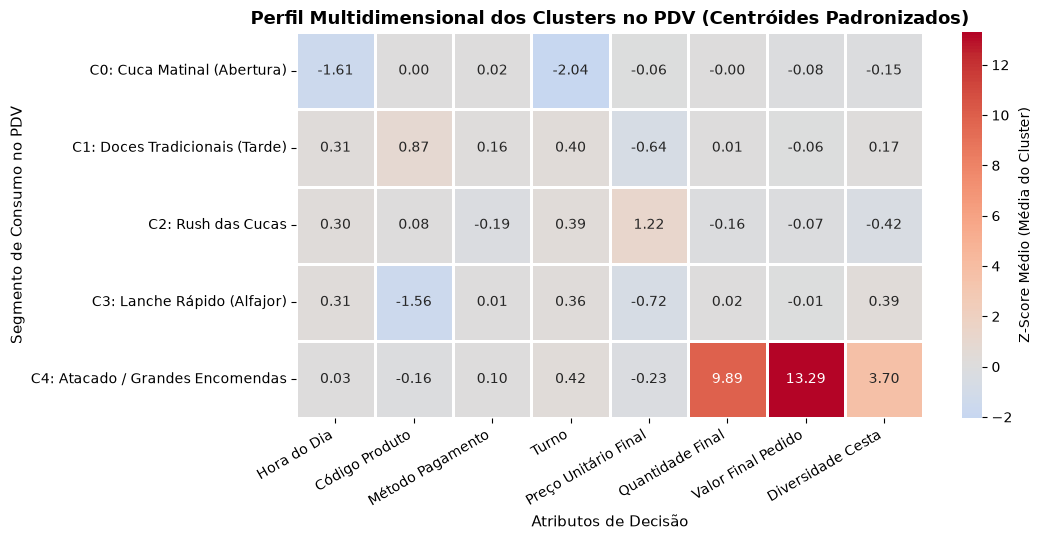

,Cluster,Amostras,% Base,Horário Médio,Turno Predom.,Qtd Média,Preço Unit. Médio,Ticket Médio,Top Produto
0,C0: Cuca Matinal (Abertura),493,15.8%,10.0h,Manhã,2.69 un,R$ 11.78,R$ 29.38,CUCA_ALEMÃ
1,C1: Doces Tradicionais (Tarde),1039,33.4%,15.7h,Tarde,2.78 un,R$ 7.07,R$ 34.67,RAPADURA_MELADO
2,C2: Rush das Cucas,941,30.2%,15.6h,Tarde,1.34 un,R$ 22.13,R$ 32.60,CUCA_ALEMÃ
3,C3: Lanche Rápido (Alfajor),627,20.1%,15.7h,Tarde,2.83 un,R$ 6.44,R$ 44.92,ALFAJOR
4,C4: Atacado / Grandes Encomendas,13,0.4%,14.8h,Tarde,86.62 un,R$ 10.42,R$ 2839.38,ALFAJOR


In [417]:
# 8.3 Treinamento do K-Means K=5, Perfilamento Semântico e Dossiê dos Clusters
K_FINAL = 5
kmeans = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

# Rótulos de negócio definidos a partir do dossiê estatístico de perfilamento
cluster_labels = {
    0: 'C0: Cuca Matinal (Abertura)',
    1: 'C1: Doces Tradicionais (Tarde)',
    2: 'C2: Rush das Cucas',
    3: 'C3: Lanche Rápido (Alfajor)',
    4: 'C4: Atacado / Grandes Encomendas'
}
df_cluster['cluster_nome'] = df_cluster['cluster'].map(cluster_labels)

# -------------------------------------------------------------
# Função de Auditoria: Dossiê de Perfilamento Quantitativo
# -------------------------------------------------------------
def relatorio_perfilamento_clusters(df_data, labels_dict):
    """
    Gera automaticamente o dossiê quantitativo que justifica
    os rótulos semânticos atribuídos aos clusters.
    """
    print("=" * 80)
    print("DOSSIÊ ANALÍTICO DE PERFILAMENTO DE CLUSTERS (CLUSTER PROFILING)")
    print("=" * 80)
    for c_id in sorted(labels_dict.keys()):
        sub = df_data[df_data['cluster'] == c_id]
        pct = (len(sub) / len(df_data)) * 100
        label_nome = labels_dict[c_id]
        
        turno_dom = sub['turno'].value_counts().index[0]
        turno_pct = sub['turno'].value_counts(normalize=True).iloc[0] * 100
        
        top_skus = sub['nome_produto'].value_counts(normalize=True).head(3) * 100
        skus_str = ", ".join([f"{sku} ({p:.1f}%)" for sku, p in top_skus.items()])
        
        pag_dom = sub['metodo_pagamento'].value_counts().index[0]
        pag_pct = sub['metodo_pagamento'].value_counts(normalize=True).iloc[0] * 100
        
        print(f"\n▶ CLUSTER {c_id}: '{label_nome}'")
        print(f"  • Volume Amostral : {len(sub)} transações ({pct:.1f}% da base)")
        print(f"  • Janela Temporal : Média {sub['dia_horario'].mean():.1f}h (Min {sub['dia_horario'].min()}h - Max {sub['dia_horario'].max()}h) | {turno_dom} ({turno_pct:.1f}%)")
        print(f"  • Preço Unitário  : R$ {sub['preco_unitario_final'].mean():.2f} (Mediana: R$ {sub['preco_unitario_final'].median():.2f})")
        print(f"  • Quantidade/Item : {sub['quantidade_final'].mean():.2f} un (Mediana: {sub['quantidade_final'].median():.0f} un | Max: {sub['quantidade_final'].max()} un)")
        print(f"  • Ticket do Pedido: R$ {sub['valor_final_pedido'].mean():.2f} (Mediana: R$ {sub['valor_final_pedido'].median():.2f})")
        print(f"  • Top 3 Produtos  : {skus_str}")
        print(f"  • Forma Pagamento : {pag_dom} ({pag_pct:.1f}%)")
    print("\n" + "=" * 80)

# Executar e exibir o dossiê
relatorio_perfilamento_clusters(df_cluster, cluster_labels)

# Heatmap dos Centróides Padronizados (Z-Scores)
df_centers = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=features_pt,
    index=[cluster_labels[i] for i in range(K_FINAL)]
)

plt.figure(figsize=(11, 5.5))
sns.heatmap(
    df_centers,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=1,
    cbar_kws={'label': 'Z-Score Médio (Média do Cluster)'}
)
plt.title('Perfil Multidimensional dos Clusters no PDV (Centróides Padronizados)', fontsize=13, fontweight='bold')
plt.xlabel('Atributos de Decisão', fontsize=11)
plt.ylabel('Segmento de Consumo no PDV', fontsize=11)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/04_heatmap_centroides_clusters.png', dpi=300)
plt.show()

# Tabela descritiva de médias operacionais reais
perfil_resumo = []
for c in range(K_FINAL):
    sub = df_cluster[df_cluster['cluster'] == c]
    top_prod = sub['nome_produto'].value_counts().index[0]
    top_turno = sub['turno'].value_counts().index[0]
    perfil_resumo.append({
        'Cluster': cluster_labels[c],
        'Amostras': len(sub),
        '% Base': f"{(len(sub)/len(df_cluster))*100:.1f}%",
        'Horário Médio': f"{sub['dia_horario'].mean():.1f}h",
        'Turno Predom.': top_turno,
        'Qtd Média': f"{sub['quantidade_final'].mean():.2f} un",
        'Preço Unit. Médio': f"R$ {sub['preco_unitario_final'].mean():.2f}",
        'Ticket Médio': f"R$ {sub['valor_final_pedido'].mean():.2f}",
        'Top Produto': top_prod
    })

df_perfil_resumo = pd.DataFrame(perfil_resumo)
display(df_perfil_resumo)


### 8.4 Visualização Multidimensional 2D com PCA e Biplot de Cargas (Feature Loadings)

O PCA projeta o espaço de 8 dimensões no plano ortogonal $(	ext{PC}_1, 	ext{PC}_2)$ que retém a maior proporção de variância global (40,5%).
Para resolver o problema da interpretação dos eixos, adicionamos os **vetores de carga do Biplot**, mostrando matematicamente como cada grandeza original (valor do pedido, horário, quantidade) influencia a posição de cada ponto no plano.


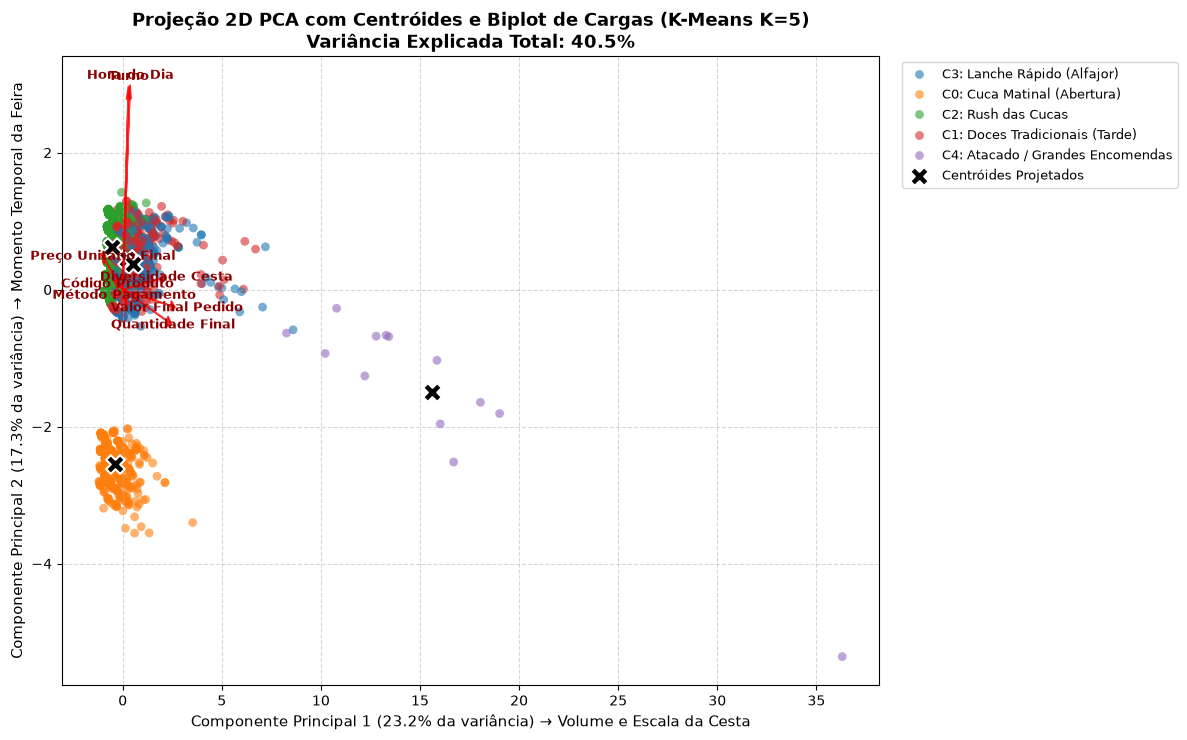

In [418]:
# 8.4 PCA 2D com Centróides e Biplot de Cargas
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca2d = pca_2d.fit_transform(X_scaled)
df_cluster['pca1'] = X_pca2d[:, 0]
df_cluster['pca2'] = X_pca2d[:, 1]
centroids_2d = pca_2d.transform(kmeans.cluster_centers_)

var1 = pca_2d.explained_variance_ratio_[0] * 100
var2 = pca_2d.explained_variance_ratio_[1] * 100

plt.figure(figsize=(12, 7.5))
palette = sns.color_palette('tab10', K_FINAL)

# Dispersão dos pontos
sns.scatterplot(
    data=df_cluster,
    x='pca1',
    y='pca2',
    hue='cluster_nome',
    palette=palette,
    alpha=0.6,
    s=40,
    edgecolor='none'
)

# Centróides projetados
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c='black',
    s=180,
    marker='X',
    edgecolors='white',
    linewidth=1.5,
    label='Centróides Projetados',
    zorder=5
)

# Biplot - Vetores de carga das grandezas originais
scale_factor = 4.0
for i, feat in enumerate(features_pt):
    vx = pca_2d.components_[0, i] * scale_factor
    vy = pca_2d.components_[1, i] * scale_factor
    plt.arrow(0, 0, vx, vy, color='red', alpha=0.8, head_width=0.15, head_length=0.2, linewidth=1.2, zorder=6)
    plt.text(vx * 1.12, vy * 1.12, feat, color='darkred', fontsize=9, fontweight='bold', ha='center', va='center', zorder=7)

plt.title(f'Projeção 2D PCA com Centróides e Biplot de Cargas (K-Means K=5)\nVariância Explicada Total: {var1+var2:.1f}%', fontsize=13, fontweight='bold')
plt.xlabel(f'Componente Principal 1 ({var1:.1f}% da variância) → Volume e Escala da Cesta', fontsize=11)
plt.ylabel(f'Componente Principal 2 ({var2:.1f}% da variância) → Momento Temporal da Feira', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/02_pca_2d_clusters_biplot.png', dpi=300)
plt.show()


### 8.5 Projeção Tridimensional PCA ($	ext{PC}_1 	imes 	ext{PC}_2 	imes 	ext{PC}_3$) via Axes3D

Incorporando a 3ª componente principal ($	ext{PC}_3$), a variância explicada acumulada atinge **54,2%**.
Esta terceira dimensão isola o efeito do **Preço Unitário Final**, permitindo visualizar nitidamente no espaço 3D a separação entre itens de ticket unitário elevado (Cucas Inteiras) e itens de baixo preço unitário (Alfajores e Rapaduras).


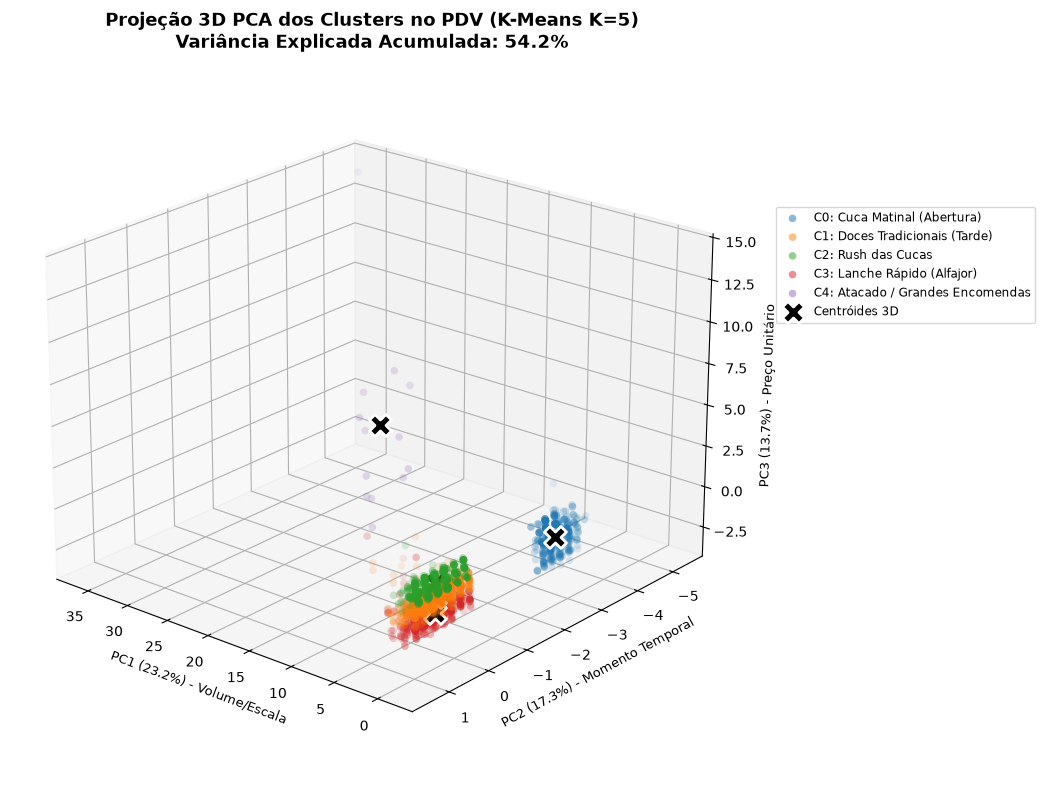

In [419]:
# 8.5 Projeção Tridimensional PCA (PC1 x PC2 x PC3)
pca_3d = PCA(n_components=3, random_state=RANDOM_STATE)
X_pca3d = pca_3d.fit_transform(X_scaled)
centroids_3d = pca_3d.transform(kmeans.cluster_centers_)
var_3d = pca_3d.explained_variance_ratio_ * 100

fig = plt.figure(figsize=(11, 8))
ax = fig.add_subplot(111, projection='3d')

for c_id in range(K_FINAL):
    mask = df_cluster['cluster'] == c_id
    ax.scatter(
        X_pca3d[mask, 0],
        X_pca3d[mask, 1],
        X_pca3d[mask, 2],
        color=palette[c_id],
        label=cluster_labels[c_id],
        alpha=0.5,
        s=30,
        edgecolor='none'
    )

ax.scatter(
    centroids_3d[:, 0],
    centroids_3d[:, 1],
    centroids_3d[:, 2],
    c='black',
    marker='X',
    s=250,
    edgecolors='white',
    linewidth=2,
    label='Centróides 3D',
    depthshade=False
)

ax.set_title(f'Projeção 3D PCA dos Clusters no PDV (K-Means K=5)\nVariância Explicada Acumulada: {sum(var_3d):.1f}%', fontsize=13, fontweight='bold')
ax.set_xlabel(f'PC1 ({var_3d[0]:.1f}%) - Volume/Escala', fontsize=9)
ax.set_ylabel(f'PC2 ({var_3d[1]:.1f}%) - Momento Temporal', fontsize=9)
ax.set_zlabel(f'PC3 ({var_3d[2]:.1f}%) - Preço Unitário', fontsize=9)
ax.view_init(elev=22, azim=130)
ax.legend(bbox_to_anchor=(1.05, 0.8), loc='upper left', fontsize=8.5)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/03_pca_3d_clusters.png', dpi=300)
plt.show()


### 8.6 Motor de Inferência e Recomendação em Tempo Real no Checkout do PDV

Demonstração prática do motor de recomendação no checkout:
1. Um novo pedido chega ao caixa da feira (ex.: 1 Alfajor unitário de R$ 6,00 às 16h).
2. O sistema padroniza o vetor de entrada via `scaler.transform`.
3. O K-Means classifica o pedido no cluster correspondente (`kmeans.predict`).
4. O ponto é projetado visualmente no mapa PCA via `pca_2d.transform`.
5. O PDV exibe a recomendação estratégica de cross-selling pré-configurada para o perfil.


=== EVENTO DE CHECKOUT NO PDV ===
Item no Carrinho: Alfajor Preto (R$ 6,00) | Horario: 16:00 (Tarde)
Cluster Identificado: C3: Lanche Rápido (Alfajor)
Acao Recomendada no Caixa: Sugestao PDV: Leve mais 3 Alfajores com desconto progressivo no pacote x4!


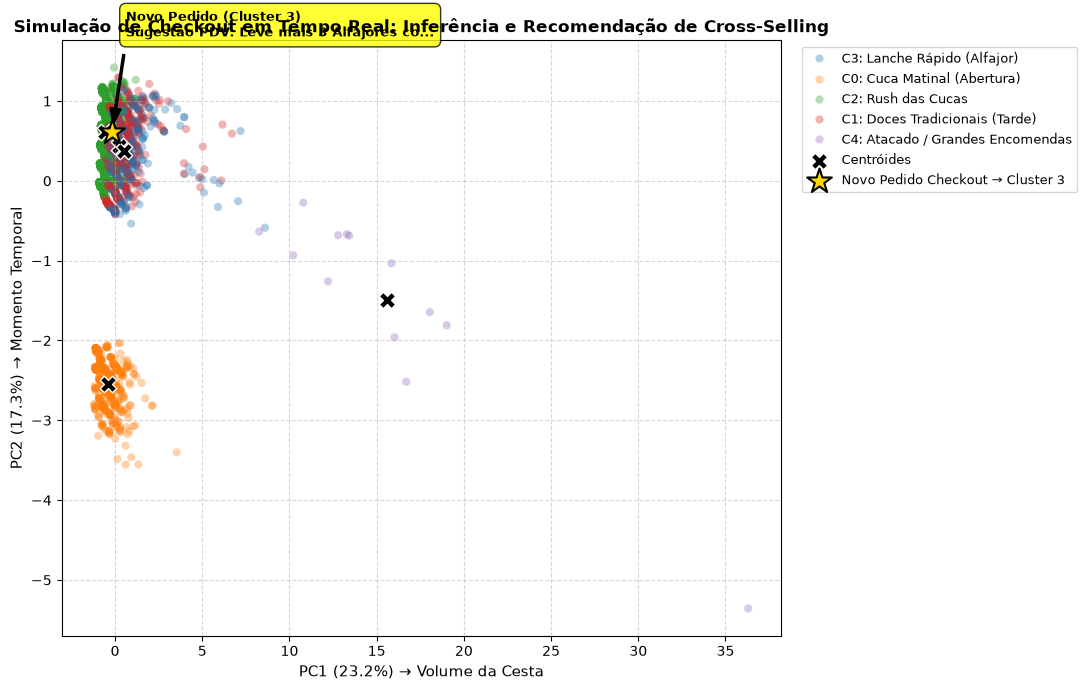

In [420]:
# 8.6 Simulação de Inferência em Tempo Real no Checkout
novo_pedido = pd.DataFrame([{
    'dia_horario': 16,
    'prod_code': le_prod.transform(['ALFAJOR'])[0],
    'metodo_code': le_metodo.transform(['Dinheiro'])[0],
    'turno_code': le_turno.transform(['Tarde'])[0],
    'preco_unitario_final': 6.0,
    'quantidade_final': 1.0,
    'valor_final_pedido': 6.0,
    'qnt_repeticoes_num': 1.0
}])

# Inferência determinística no modelo
novo_scaled = scaler.transform(novo_pedido[features_cluster])
pred_cluster = kmeans.predict(novo_scaled)[0]
novo_pca = pca_2d.transform(novo_scaled)

regras_recomendacao = {
    0: 'Sugestao PDV: Adicione Cuca Alema Quentinha ou Biscoito Colonial ao Cafe da Manha!',
    1: 'Sugestao PDV: Leve o Combo Promocional de Rapadura de Melado (Pacote x3)!',
    2: 'Sugestao PDV: Experimente a Cuca Alema Recheada e Alfajor Gourmet para viagem!',
    3: 'Sugestao PDV: Leve mais 3 Alfajores com desconto progressivo no pacote x4!',
    4: 'Sugestao PDV: Atendimento Atacado / Emissao de NF com Bonificacao de Fardo!'
}

print(f"=== EVENTO DE CHECKOUT NO PDV ===")
print(f"Item no Carrinho: Alfajor Preto (R$ 6,00) | Horario: 16:00 (Tarde)")
print(f"Cluster Identificado: {cluster_labels[pred_cluster]}")
print(f"Acao Recomendada no Caixa: {regras_recomendacao[pred_cluster]}")

# Visualização da inferência no espaço PCA
plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_cluster,
    x='pca1',
    y='pca2',
    hue='cluster_nome',
    palette=palette,
    alpha=0.35,
    s=35,
    edgecolor='none'
)
plt.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c='black',
    s=140,
    marker='X',
    edgecolors='white',
    label='Centróides'
)
plt.scatter(
    novo_pca[0, 0],
    novo_pca[0, 1],
    c='gold',
    marker='*',
    s=350,
    edgecolors='black',
    linewidth=1.5,
    label=f'Novo Pedido Checkout → Cluster {pred_cluster}',
    zorder=10
)
plt.annotate(
    f'Novo Pedido (Cluster {pred_cluster})\n{regras_recomendacao[pred_cluster][:38]}...',
    xy=(novo_pca[0, 0], novo_pca[0, 1]),
    xytext=(novo_pca[0, 0] + 0.8, novo_pca[0, 1] + 1.2),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
    fontsize=9,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.8)
)
plt.title('Simulação de Checkout em Tempo Real: Inferência e Recomendação de Cross-Selling', fontsize=12, fontweight='bold')
plt.xlabel(f'PC1 ({var1:.1f}%) → Volume da Cesta', fontsize=11)
plt.ylabel(f'PC2 ({var2:.1f}%) → Momento Temporal', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}/05_simulacao_checkout_recomendacao.png', dpi=300)
plt.show()


### 8.7 Exportação do Modelo para o CLI (Joblib)

Salvamos o modelo , o , os encoders e os dicionários de regras em um único arquivo  na raiz do projeto, permitindo a execução do script [](./cli.py).


In [421]:
# 8.7 Exportação do Modelo para uso no cli.py
import joblib

bundle = {
    "kmeans": kmeans,
    "scaler": scaler,
    "encoders": {"prod": le_prod, "metodo": le_metodo, "turno": le_turno},
    "features": features_cluster,
    "cluster_labels": cluster_labels,
    "regras_recomendacao": regras_recomendacao,
    "mapa_produtos": mapa_produtos,
}

joblib.dump(bundle, "modelo_checkout.joblib")
print("✔ Modelo salvo com sucesso em 'modelo_checkout.joblib'!")


✔ Modelo salvo com sucesso em 'modelo_checkout.joblib'!
